In [1]:
from math import nan
import numpy as np
import pandas as pd

df = pd.read_json('../books_dirty.json')

clean = df.to_numpy()
clean[clean == ""] = nan
df = pd.DataFrame(clean)

df = df.dropna()
for x in df.index:
    if (str(df.loc[x, 6])) == 'N/A' or (df.loc[x, 6]) <0:
        df.loc[x, 6] = 0
    if (str(df.loc[x, 4])) == 'Unknown':
        df.loc[x,4] = 0
    if (str(df.loc[x, 14])) == 'N/A':
        df.loc[x,14] = '1/1/2026'
    if (str(df.loc[x,5])) == 'N/A' or (df.loc[x,5]) < 0:
        df.loc[x,5] = 0
    if (str(df.loc[x,7])) == 'Unknown' or (df.loc[x,7]) < 0:
        df.loc[x,7] = 0
    if (str(df.loc[x,8])) == 'N/A' or (df.loc[x,8]) < 0:
        df.loc[x,8] = nan
    if (str(df.loc[x,13])) == 'Unknown' or (df.loc[x,13]) < 0:
        df.loc[x,13] = 0

df = df.dropna()

df[4] = df[4].clip(lower=1800, upper=2026)
df[14] =pd.to_datetime(df[14], format='mixed')
df[3] = df[3].str.title()
df[9] = df[9].str.title()
df[10] = df[10].str.title()
df[11] = df[11].str.title()

df.drop_duplicates(inplace=True)

print(df.to_string)


<bound method DataFrame.to_string of                                        0              1          2   \
30   bab2a23e-b5c8-4d08-a89b-5563c51ada64   Book Title 6  Author 29   
59   19bceebb-e781-46bf-93e1-c6e44880cd0e   Book Title 7  Author 22   
102  989060c5-965d-4cd5-84c5-ba91f1159087   Book Title 4  Author 29   
219  6b71e8e9-5ae0-4159-b044-17049a5c4957  Book Title 18  Author 29   
307  73ebc9a4-0a25-4f5c-b933-2e183c2374ab  Book Title 14  Author 15   

                  3     4    5     6     7      8                    9   \
30           Romance  1800    0  4.95  4877  17.69       Sunshine Media   
59           Mystery  1800    0     0     0  14.03       Sunshine Media   
102       Technology  2005  180     0  1278  19.04  Old Tree Publishing   
219       Technology  1800    0     0  3020  157.6       Sunshine Media   
307  Science Fiction  1800    0  5.31  1974  196.7       Galactic Books   

          10         11     12     13                         14     15  \
30   Engli

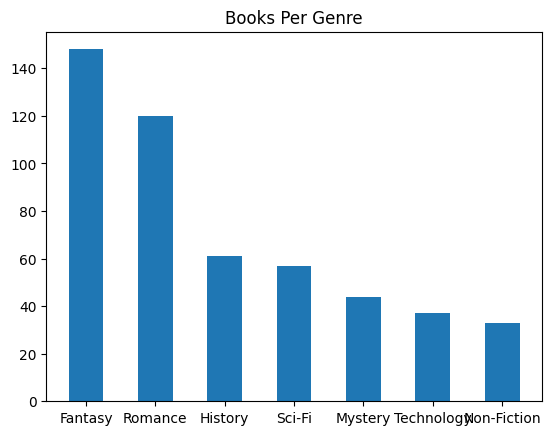

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_json('../books.json')

books = df.groupby('genre')['genre'].count().sort_values(ascending=False)

x = np.array(df['genre'].unique())
y = np.array(books)

plt.bar(x,y, width= .5)
plt.title('Books Per Genre')
plt.show()


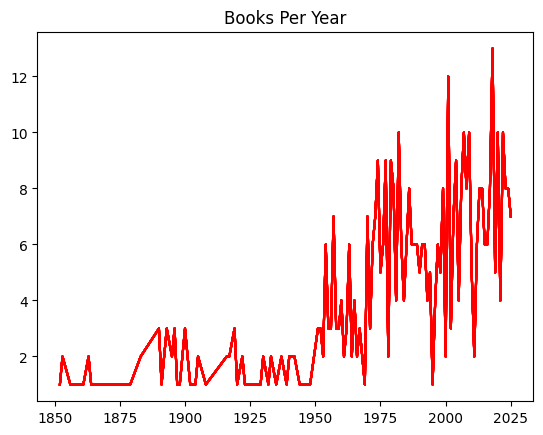

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_json('../books.json')

books = df.groupby('publication_year').count()

plt.plot(books, color='r')
plt.title('Books Per Year')
plt.show()

available
False    254
True     246
Name: available, dtype: int64


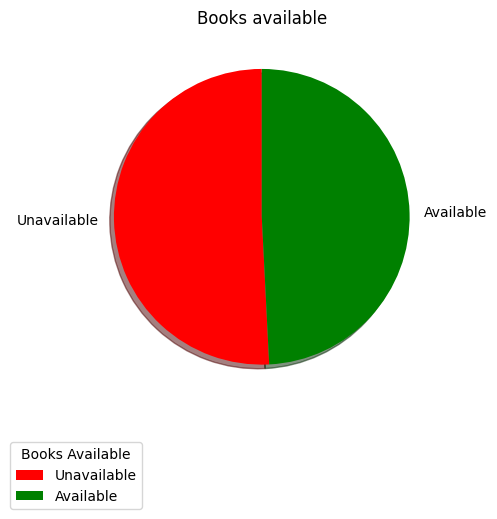

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_json('../books.json')

books = df.groupby('available')['available'].count()
mylables = ['Unavailable', 'Available']
print(books)

plt.pie(books, labels=mylables, shadow=True, startangle=90 , colors=['red', 'green'])
plt.title('Books available')
plt.legend(title='Books Available', loc = 'center left', bbox_to_anchor=(-.2,-.2))
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

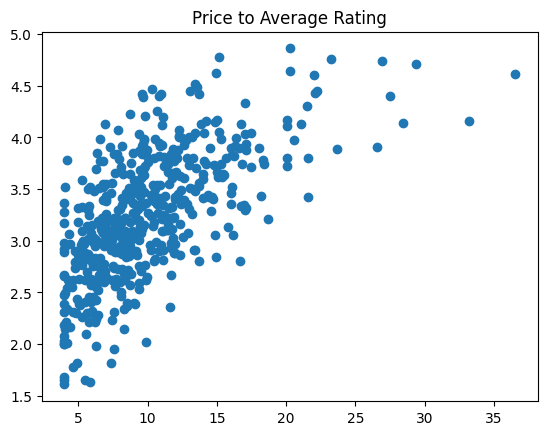

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_json('../books.json')

plt.scatter(df.price_usd,df.average_rating)
plt.title('Price to Average Rating')
plt.show


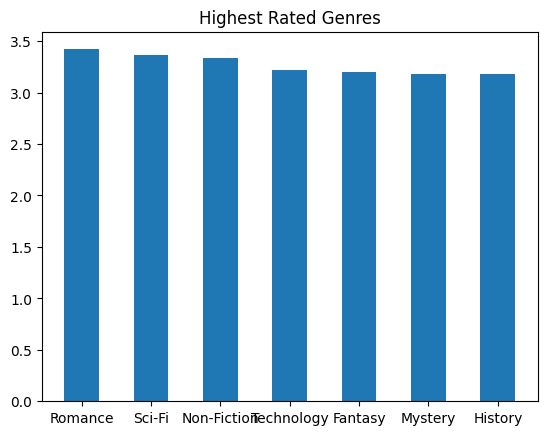

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_json('../books.json')

#weighted_rating = (ratings_count / (ratings_count + m)) * average_rating
 #  + (m / (ratings_count + m)) * global_average
#average_rating = books rating
 #  ratings_count = number of ratings
 #  global_average = mean rating of all books
  # m = minimum ratings threshold (50-100 recommended)

global_average = df['average_rating'].mean()
m=75
df["weighted_rating"] = (
    (df["ratings_count"] / (df["ratings_count"] + m)) * df["average_rating"]
    + (m / (df["ratings_count"] + m)) * global_average
)

genre_ratings = (
    df.groupby("genre")["weighted_rating"]
      .mean()
      .sort_values(ascending=False)
)


x = np.array(df['genre'].unique())
y = np.array(genre_ratings)

plt.bar(x,y, width= .5)
plt.title('Highest Rated Genres')
plt.show()